In [23]:
import os
if not os.path.exists('exchange_rate_analysis'):
    !git clone https://github.com/matthewhirokawa/exchange_rate_analysis.git
%cd exchange_rate_analysis

"\nimport os\nif not os.path.exists('exchange_rate_analysis'):\n    !git clone https://github.com/matthewhirokawa/exchange_rate_analysis.git\n%cd exchange_rate_analysis\n"

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [25]:
#read in monthly sentiment data and convert month to datetime
#datetime defaults to first day of month
monthly_sentiment_nltk = pd.read_csv('data/monthly_sentiment_nltk.csv')
monthly_sentiment_nltk.head()

monthly_sentiment_textblob = pd.read_csv('data/monthly_sentiment_textblob.csv')
#monthly_sentiment_textblob['Month'] = pd.to_datetime(monthly_sentiment_textblob['Month'])
monthly_sentiment_textblob.head()

,Month,Relation,Sentiment
0,2024-01,China-Canada,0.003673
1,2024-01,USA-Canada,0.008041
2,2024-01,USA-China,0.018102
3,2024-02,China-Canada,0.005115
4,2024-02,USA-Canada,0.005889


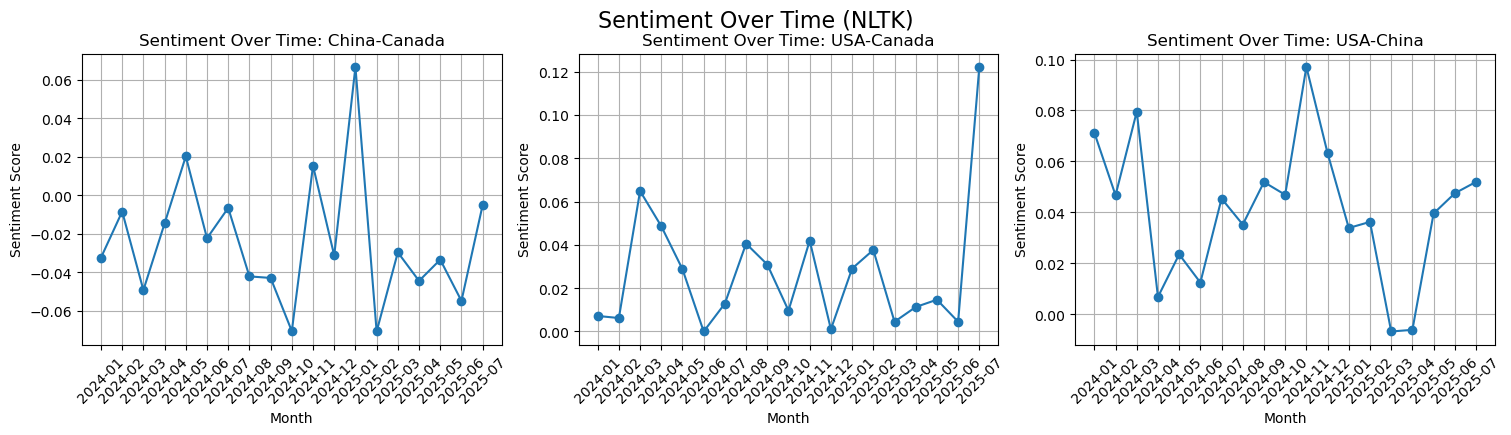

In [50]:
#Plot graphs of sentiment over time for NLTK library
unique_relations = monthly_sentiment_nltk['Relation'].unique()

#plot using pyplot to show on github
n = len(unique_relations)

# Create 1 row with n columns
fig, axes = plt.subplots(1, n, figsize=(n * 5, 4), constrained_layout=True)

# If n = 1, axes is not iterable, so handle that case
if n == 1:
    axes = [axes]

#graph all on same row
for idx, relation in enumerate(unique_relations):
    sub_df = monthly_sentiment_nltk[monthly_sentiment_nltk['Relation'] == relation]
    ax = axes[idx]
    ax.plot(sub_df['Month'], sub_df['Sentiment'], marker='o', linestyle='-')
    ax.set_title(f'Sentiment Over Time: {relation}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sentiment Score')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

plt.suptitle('Sentiment Over Time (NLTK)', fontsize = 16)
plt.show()

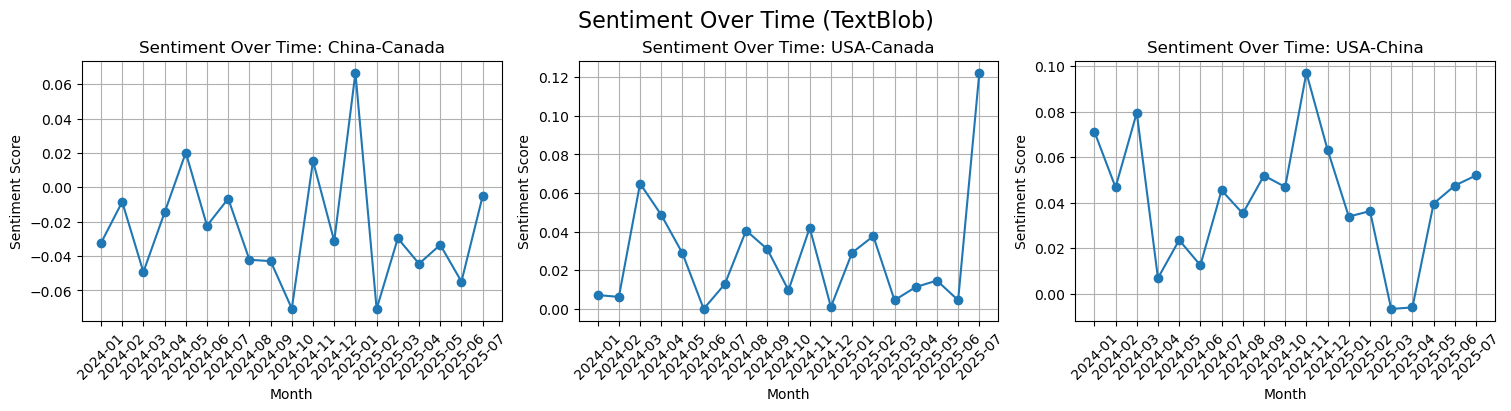

In [52]:
#Sentiment over time for Textblob
unique_relations = monthly_sentiment_textblob['Relation'].unique()

n = len(unique_relations)

# Create 1 row with n columns
fig, axes = plt.subplots(1, n, figsize=(n * 5, 4), constrained_layout=True)

# If n = 1, axes is not iterable, so handle that case
if n == 1:
    axes = [axes]

for idx, relation in enumerate(unique_relations):
    sub_df = monthly_sentiment_nltk[monthly_sentiment_nltk['Relation'] == relation]

    ax = axes[idx]
    ax.plot(sub_df['Month'], sub_df['Sentiment'], marker='o', linestyle='-')
    ax.set_title(f'Sentiment Over Time: {relation}')
    ax.set_xlabel('Month')
    ax.set_ylabel('Sentiment Score')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True)

plt.suptitle('Sentiment Over Time (TextBlob)', fontsize = 16)
plt.show()
